In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:
design_matrix = pd.read_csv(
    "../tests/input_files/design_sepsis.tsv",
    sep="\t"
)

In [3]:
design_matrix['group'] = design_matrix['group'].astype(str)

In [4]:
design_matrix = design_matrix.sort_values('group').reset_index(drop=True)
design_matrix.loc[150:, 'group'] = 3
design_matrix['group'].value_counts()

group
2    76
1    74
3    47
Name: count, dtype: int64

In [5]:
qm = QuantMatrix(
    quantification_file="../tests/input_files/data_sepsis.tsv",
    design_matrix_file=design_matrix,
).filter(
    remove_zero_rows=True,
    remove_n_zero_rows=True,
    max_n_zeros=int(design_matrix.shape[0] / 2),
).normalize(method="mean").quantify(method="top_n", top_n=3, summarization_method="mean")

/Users/aaron/Documents/projects/dpks/DPKS/dpks/quantification.py:94: RuntimeWarning: Mean of empty slice
  quantification: np.ndarray = np.nanmean(


In [6]:
group_a = qm.get_samples(1)

In [7]:
fast_qm = qm.copy().compare(
    method="fast_ols",
    comparison=("2", "1")
)

In [8]:
linregress_qm = qm.copy().compare(
    method="linregress",
    comparison=("2", "1")
)

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

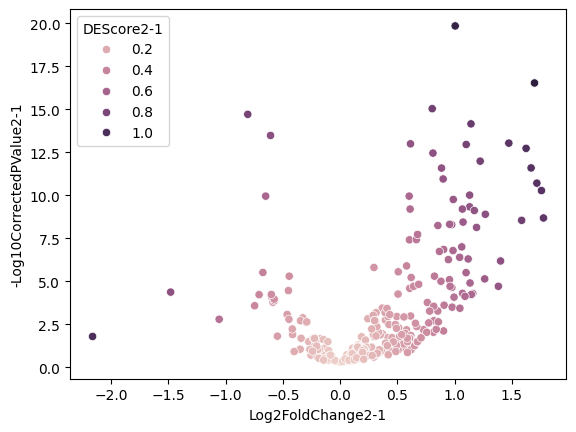

In [9]:
sns.scatterplot(
    data=fast_qm.row_annotations,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1",
    hue="DEScore2-1",
)

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

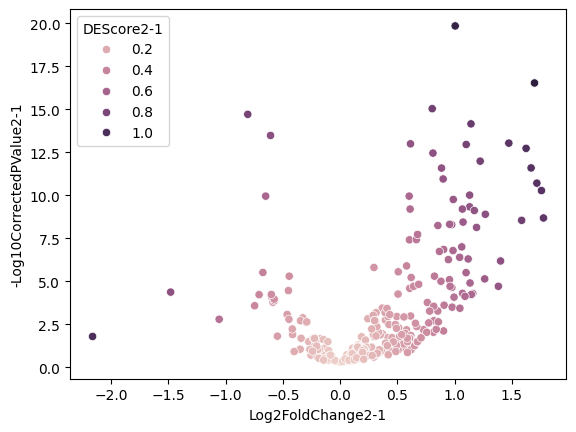

In [10]:
sns.scatterplot(
    data=linregress_qm.row_annotations,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1",
    hue="DEScore2-1",
)

<Axes: xlabel='Log2FoldChange2-1', ylabel='Log2FoldChange2-1'>

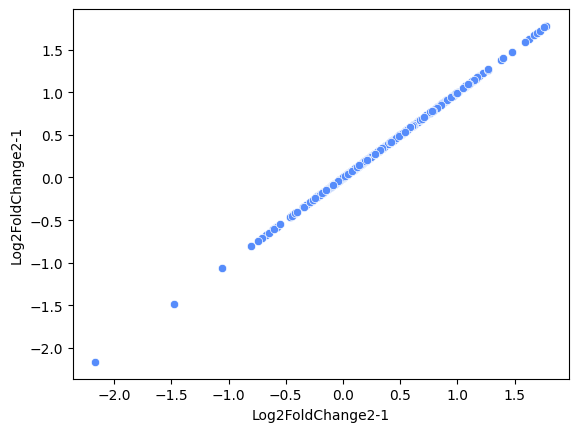

In [11]:
sns.scatterplot(
    x=linregress_qm.row_annotations['Log2FoldChange2-1'],
    y=fast_qm.row_annotations['Log2FoldChange2-1']
)

In [12]:
fast_qm.row_annotations

,Protein,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,Group1RepCounts,CorrectedPValue2-1,-Log10CorrectedPValue2-1
0,P08603,0.016398,25.905169,25.872751,0.546366,0.525536,0.032418,0.713596,76,74,0.392601,0.406048
1,P02671,0.035666,29.754827,29.827696,0.663124,0.818528,-0.072869,0.552208,76,74,0.323479,0.490153
2,P00450,0.073283,26.986933,26.865878,0.398278,0.464603,0.121055,0.090612,76,74,0.077045,1.113258
3,P05156,0.063336,23.482155,23.368675,0.474855,0.514594,0.113479,0.165180,76,74,0.121031,0.917105
4,P10643,0.023801,23.336389,23.384901,0.650763,0.719947,-0.048512,0.667628,76,74,0.377768,0.422775
...,...,...,...,...,...,...,...,...,...,...,...,...
313,P01602,0.198599,20.474537,20.061583,1.082883,1.186228,0.412954,0.062525,56,53,0.056486,1.248061
314,P04220,0.066897,22.231225,22.375087,2.068762,1.842520,-0.143862,0.697573,62,54,0.389173,0.409858
315,P01617,0.196030,22.164593,21.743990,1.650614,1.898496,0.420603,0.286940,47,37,0.190097,0.721024
316,P01616,0.543925,22.283575,21.192000,1.634836,1.409982,1.091575,0.000034,75,71,0.000076,4.119607


In [13]:
linregress_qm.row_annotations

,Protein,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,Group1RepCounts,CorrectedPValue2-1,-Log10CorrectedPValue2-1
0,P08603,0.016398,25.905169,25.872751,0.546366,0.525536,0.032418,0.713596,76,74,0.392601,0.406048
1,P02671,0.035666,29.754827,29.827696,0.663124,0.818528,-0.072869,0.552208,76,74,0.323479,0.490153
2,P00450,0.073283,26.986933,26.865878,0.398278,0.464603,0.121055,0.090612,76,74,0.077045,1.113258
3,P05156,0.063336,23.482155,23.368675,0.474855,0.514594,0.113479,0.165180,76,74,0.121031,0.917105
4,P10643,0.023801,23.336389,23.384901,0.650763,0.719947,-0.048512,0.667628,76,74,0.377768,0.422775
...,...,...,...,...,...,...,...,...,...,...,...,...
313,P01602,0.198599,20.474537,20.061583,1.082883,1.186228,0.412954,0.062525,56,53,0.056486,1.248061
314,P04220,0.066897,22.231225,22.375087,2.068762,1.842520,-0.143862,0.697573,62,54,0.389173,0.409858
315,P01617,0.196030,22.164593,21.743990,1.650614,1.898496,0.420603,0.286940,47,37,0.190097,0.721024
316,P01616,0.543925,22.283575,21.192000,1.634836,1.409982,1.091575,0.000034,75,71,0.000076,4.119607


<Axes: xlabel='CorrectedPValue2-1', ylabel='CorrectedPValue2-1'>

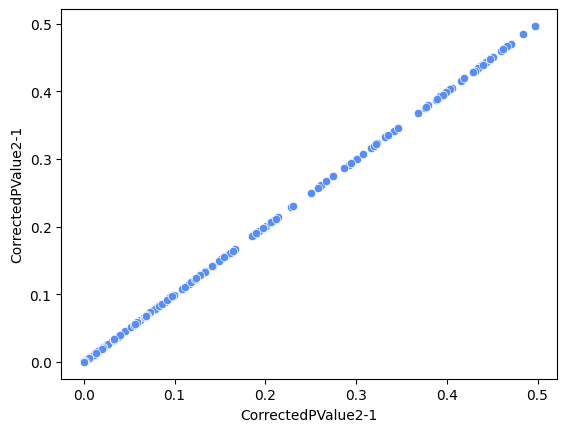

In [14]:
sns.scatterplot(
    x=linregress_qm.row_annotations['CorrectedPValue2-1'],
    y=fast_qm.row_annotations['CorrectedPValue2-1']
)

<Axes: xlabel='DEScore2-1', ylabel='DEScore2-1'>

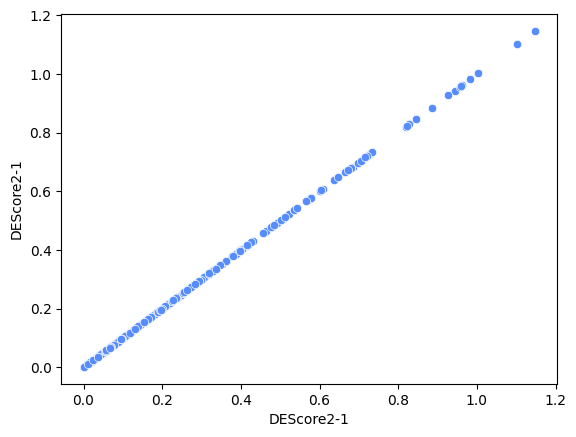

In [16]:
sns.scatterplot(
    x=linregress_qm.row_annotations['DEScore2-1'],
    y=fast_qm.row_annotations['DEScore2-1']
)